# RPT Experiment

用于执行 `（5个循环 + 1个RPT） * 14` 的完整 PyBaMM 试验方案。

本 notebook 已取消 `1 个 block` 的预览流程，默认直接运行 `14 个 block`。

In [1]:
from pathlib import Path
import json
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    raise FileNotFoundError("Cannot locate project root from current working directory")

ROOT = find_project_root(Path.cwd().resolve())
OUT_DIR = ROOT / "notebooks" / "experiment"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR


PosixPath('/home/netszx/AlphaB/notebooks/experiment')

In [2]:
# ===== 协议配置 =====
BLOCKS = 14
CYCLES_PER_CHECKPOINT = 5
DISCHARGE_C_RATE = 1.0
CHARGE_STAGE_1_C_RATE = 1.5
CHARGE_STAGE_2_C_RATE = 0.8
CV_VOLTAGE = 4.2
CV_CUTOFF = "C/100"
LOW_VOLTAGE_CUTOFF = 2.5
PERIOD = "1 minute"
SOC_STAGE_1 = 0.30
SOC_STAGE_2 = 0.50


In [3]:
def soc_delta_to_hours(soc_delta: float, c_rate: float) -> float:
    if c_rate <= 0:
        raise ValueError("C-rate must be positive")
    return soc_delta / c_rate

stage1_hours = soc_delta_to_hours(SOC_STAGE_1, CHARGE_STAGE_1_C_RATE)
stage2_hours = soc_delta_to_hours(SOC_STAGE_2, CHARGE_STAGE_2_C_RATE)

ageing_cycle_steps = [
    f"Discharge at {DISCHARGE_C_RATE}C until {LOW_VOLTAGE_CUTOFF} V",
    f"Charge at {CHARGE_STAGE_1_C_RATE}C for {stage1_hours:.6f} hours",
    f"Charge at {CHARGE_STAGE_2_C_RATE}C for {stage2_hours:.6f} hours",
    f"Hold at {CV_VOLTAGE} V until {CV_CUTOFF}",
]

rpt_steps = [
    "Rest for 30 minutes",
    "Discharge at 0.1C until 2.5 V",
    "Rest for 30 minutes",
    "Charge at 0.1C until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 60 minutes",
    "Discharge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Charge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Discharge at C/5 for 60 minutes",
    "Rest for 60 minutes",
    "Discharge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Charge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Discharge at C/5 for 90 minutes",
    "Rest for 60 minutes",
    "Discharge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Charge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Discharge at C/5 for 90 minutes",
    "Rest for 60 minutes",
    "Discharge at 1C for 10 seconds",
    "Rest for 10 minutes",
    "Charge at 1C for 10 seconds",
    "Rest for 10 minutes",
]

rpt_extractors = {
    "capacity_step_index": 1,
    "dcir_rest_step_index": 5,
    "dcir_pulse_step_index": 6,
    "hppc_pulse_step_index": 6,
    "low_rate_discharge_step_index": 1,
    "low_rate_charge_step_index": 3,
    "pulse_pairs": [
        {"label": "100_soc", "rest_step_index": 5,  "discharge_pulse_step_index": 6,  "charge_pulse_step_index": 8},
        {"label": "80_soc",  "rest_step_index": 11, "discharge_pulse_step_index": 12, "charge_pulse_step_index": 14},
        {"label": "50_soc",  "rest_step_index": 17, "discharge_pulse_step_index": 18, "charge_pulse_step_index": 20},
        {"label": "20_soc",  "rest_step_index": 23, "discharge_pulse_step_index": 24, "charge_pulse_step_index": 26},
    ],
}

protocol = {
    "period": PERIOD,
    "cycles_per_checkpoint": CYCLES_PER_CHECKPOINT,
    "n_checkpoints": BLOCKS,
    "ageing_cycle_steps": ageing_cycle_steps,
    "rpt_steps": rpt_steps,
    "rpt_extractors": rpt_extractors,
}

protocol_path = OUT_DIR / "protocol_5cycles_1rpt_14blocks.json"
protocol_path.write_text(json.dumps(protocol, ensure_ascii=False, indent=2), encoding="utf-8")

rows = []
for checkpoint in range(1, BLOCKS + 1):
    for step_index, instruction in enumerate(ageing_cycle_steps, start=1):
        rows.append({
            "segment_id": checkpoint,
            "checkpoint": checkpoint,
            "repeat_count": CYCLES_PER_CHECKPOINT,
            "step_index": step_index,
            "instruction": instruction,
        })
cycle_protocols = pd.DataFrame(rows)
cycle_protocols_path = OUT_DIR / "cycle_protocols_5cycles_1rpt_14blocks.csv"
cycle_protocols.to_csv(cycle_protocols_path, index=False)
cycle_protocols.head(12)

,segment_id,checkpoint,repeat_count,step_index,instruction
0,1,1,5,1,Discharge at 1.0C until 2.5 V
1,1,1,5,2,Charge at 1.5C for 0.200000 hours
2,1,1,5,3,Charge at 0.8C for 0.625000 hours
3,1,1,5,4,Hold at 4.2 V until C/100
4,2,2,5,1,Discharge at 1.0C until 2.5 V
5,2,2,5,2,Charge at 1.5C for 0.200000 hours
6,2,2,5,3,Charge at 0.8C for 0.625000 hours
7,2,2,5,4,Hold at 4.2 V until C/100
8,3,3,5,1,Discharge at 1.0C until 2.5 V
9,3,3,5,2,Charge at 1.5C for 0.200000 hours


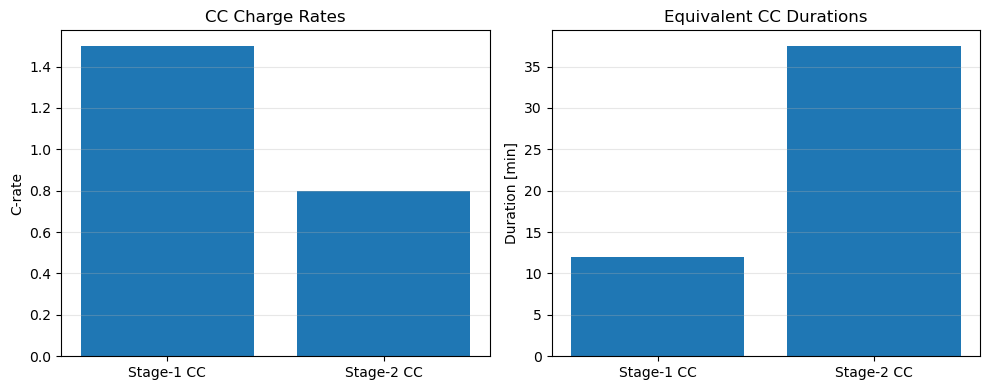

In [4]:
# 协议参数可视化
labels = ["Stage-1 CC", "Stage-2 CC"]
durations_min = [stage1_hours * 60, stage2_hours * 60]
rates = [CHARGE_STAGE_1_C_RATE, CHARGE_STAGE_2_C_RATE]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, rates)
axes[0].set_ylabel("C-rate")
axes[0].set_title("CC Charge Rates")
axes[0].grid(axis="y", alpha=0.3)
axes[1].bar(labels, durations_min)
axes[1].set_ylabel("Duration [min]")
axes[1].set_title("Equivalent CC Durations")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# 完整长跑：14 个 block
summary_csv = OUT_DIR / "coupled_summary.csv"
trace_csv = OUT_DIR / "coupled_rpt_traces.csv"
feature_csv = OUT_DIR / "coupled_rpt_features.csv"
state_json = OUT_DIR / "coupled_state.json"
cmd = [
    "python", "src/degradation/coupled_degradation_model.py",
    "--protocol-json", str(protocol_path),
    "--cycle-protocol-csv", str(cycle_protocols_path),
    "--output-csv", str(summary_csv),
    "--output-trace-csv", str(trace_csv),
    "--output-feature-csv", str(feature_csv),
    "--output-state-json", str(state_json),
]
print(" ".join(cmd))
subprocess.run(cmd, cwd=ROOT, check=True)
summary_df = pd.read_csv(summary_csv).sort_values("checkpoint").reset_index(drop=True)
if "soh_pct" not in summary_df.columns:
    summary_df["soh_pct"] = 100 * summary_df["capacity_01c_ah"] / summary_df["capacity_01c_ah"].iloc[0]
summary_df.tail()

python src/degradation/coupled_degradation_model.py --protocol-json /home/netszx/AlphaB/notebooks/experiment/protocol_5cycles_1rpt_14blocks.json --cycle-protocol-csv /home/netszx/AlphaB/notebooks/experiment/cycle_protocols_5cycles_1rpt_14blocks.csv --output-csv /home/netszx/AlphaB/notebooks/experiment/coupled_summary.csv --output-trace-csv /home/netszx/AlphaB/notebooks/experiment/coupled_rpt_traces.csv --output-feature-csv /home/netszx/AlphaB/notebooks/experiment/coupled_rpt_features.csv --output-state-json /home/netszx/AlphaB/notebooks/experiment/coupled_state.json


/home/netszx/miniforge/envs/ai4b/lib/python3.9/site-packages/pybamm/util.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
At t = 526.704 and h = 3.08092e-12, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 462.316 and h = 1.00799e-14, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 222.318 and h = 2.034e-12, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 461.462 and h = 6.48568e-13, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 221.462 and h = 1.02171e-12, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 460.736 and h = 4.76613e-12, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 220.736 and h = 8.11991e-12, the corrector converg

Saved degradation summary: /home/netszx/AlphaB/notebooks/experiment/coupled_summary.csv
Saved RPT traces: /home/netszx/AlphaB/notebooks/experiment/coupled_rpt_traces.csv
Saved RPT features: /home/netszx/AlphaB/notebooks/experiment/coupled_rpt_features.csv
Saved final state: /home/netszx/AlphaB/notebooks/experiment/coupled_state.json
 checkpoint  cycle  capacity_01c_ah  dcir_ohm  hppc_power_w  throughput_ah  lli_pct  lam_ne_pct  lam_pe_pct  neg_porosity  voltage_v  dcir_100_soc_ohm  hppc_discharge_power_100_soc_w  hppc_charge_power_100_soc_w  dcir_80_soc_ohm  hppc_discharge_power_80_soc_w  hppc_charge_power_80_soc_w  dcir_50_soc_ohm  hppc_discharge_power_50_soc_w  hppc_charge_power_50_soc_w  dcir_20_soc_ohm  hppc_discharge_power_20_soc_w  hppc_charge_power_20_soc_w  dqdv_peak_v_discharge  dqdv_peak_h_discharge  ica_area_discharge  dqdv_peak_v_charge  dqdv_peak_h_charge  ica_area_charge    soh_pct
          1      5         5.078626  0.032384     21.790610      64.407366 0.153034    0.00

,checkpoint,cycle,capacity_01c_ah,dcir_ohm,hppc_power_w,throughput_ah,lli_pct,lam_ne_pct,lam_pe_pct,neg_porosity,...,dcir_20_soc_ohm,hppc_discharge_power_20_soc_w,hppc_charge_power_20_soc_w,dqdv_peak_v_discharge,dqdv_peak_h_discharge,ica_area_discharge,dqdv_peak_v_charge,dqdv_peak_h_charge,ica_area_charge,soh_pct
9,10,50,5.048291,0.032722,21.802256,59.966692,0.572007,0.031781,0.018840,0.234214,...,0.029291,16.792789,18.212854,4.075664,-19.605278,5.048291,4.118911,-18.410387,4.985222,99.402695
10,11,55,5.045720,0.032755,21.802684,59.934192,0.603703,0.034907,0.020707,0.233378,...,0.029327,16.791265,18.213414,4.075584,-19.553833,5.045720,4.118913,-18.434167,4.982932,99.352074
11,12,60,5.043333,0.032786,21.803175,59.903918,0.634107,0.038032,0.022572,0.232578,...,0.029343,16.789040,18.214007,4.075536,-19.518083,5.043333,4.118914,-18.443488,4.980717,99.305067
12,13,65,5.041147,0.032815,21.803744,59.876057,0.663383,0.041154,0.024434,0.231809,...,0.029356,16.786705,18.214954,4.075529,-19.471462,5.041147,4.118916,-18.446526,4.978571,99.262031
13,14,70,5.039098,0.032841,21.804387,59.849925,0.691660,0.044274,0.026295,0.231070,...,0.029397,16.785271,18.216621,4.075540,-19.420598,5.039098,4.118917,-18.465164,4.976487,99.221692


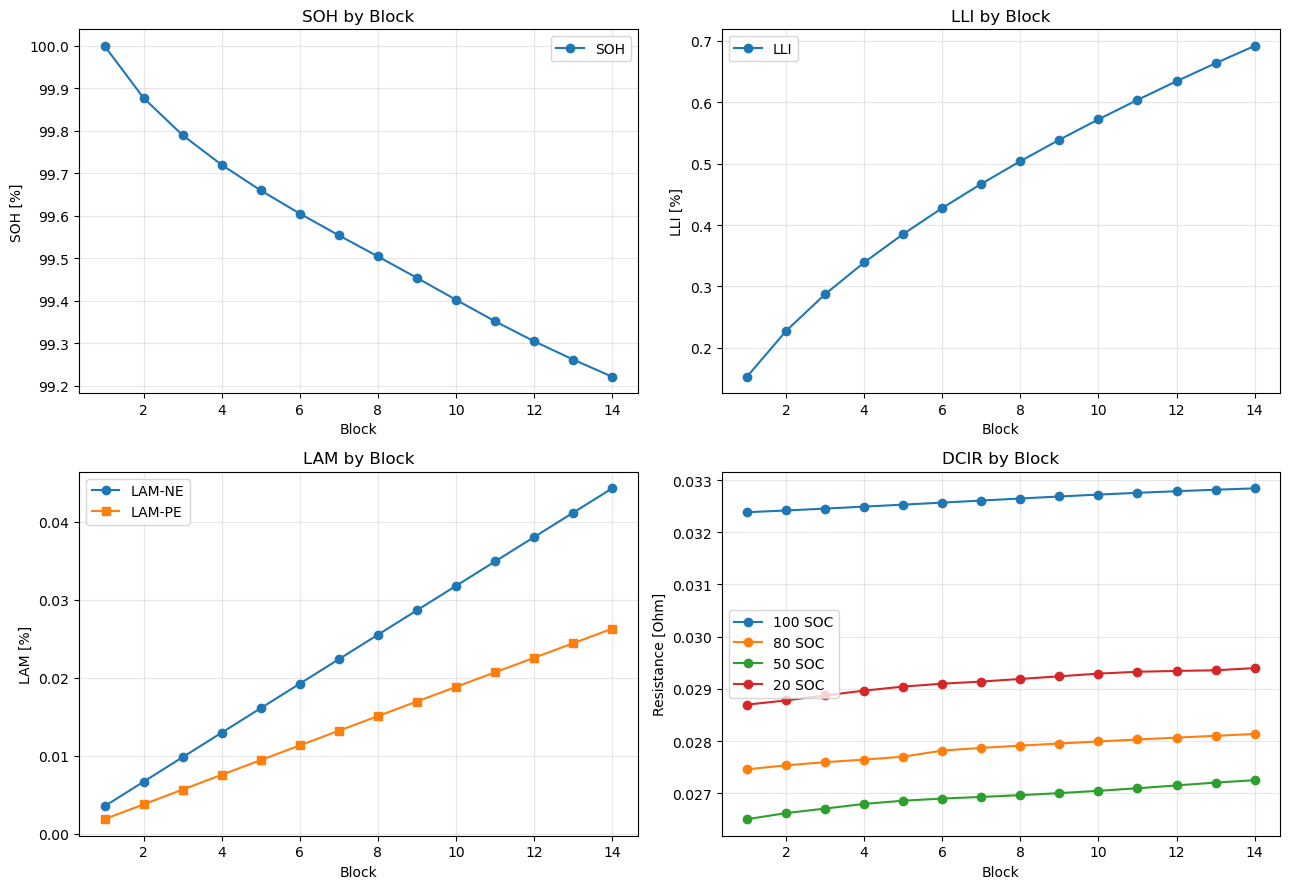

In [6]:
x = summary_df["checkpoint"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].plot(x, summary_df["soh_pct"], "o-", label="SOH")
axes[0, 0].set_title("SOH by Block")
axes[0, 0].set_xlabel("Block")
axes[0, 0].set_ylabel("SOH [%]")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()
axes[0, 1].plot(x, summary_df["lli_pct"], "o-", label="LLI")
axes[0, 1].set_title("LLI by Block")
axes[0, 1].set_xlabel("Block")
axes[0, 1].set_ylabel("LLI [%]")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()
axes[1, 0].plot(x, summary_df["lam_ne_pct"], "o-", label="LAM-NE")
axes[1, 0].plot(x, summary_df["lam_pe_pct"], "s-", label="LAM-PE")
axes[1, 0].set_title("LAM by Block")
axes[1, 0].set_xlabel("Block")
axes[1, 0].set_ylabel("LAM [%]")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()
for col in ["dcir_100_soc_ohm", "dcir_80_soc_ohm", "dcir_50_soc_ohm", "dcir_20_soc_ohm"]:
    if col in summary_df.columns:
        label = col.replace("dcir_", "").replace("_ohm", "").replace("_", " ").upper()
        axes[1, 1].plot(x, summary_df[col], "o-", label=label)
axes[1, 1].set_title("DCIR by Block")
axes[1, 1].set_xlabel("Block")
axes[1, 1].set_ylabel("Resistance [Ohm]")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()
plt.tight_layout()
plt.show()
fig.savefig(OUT_DIR / "block_metrics_overview.png", dpi=180, bbox_inches="tight")

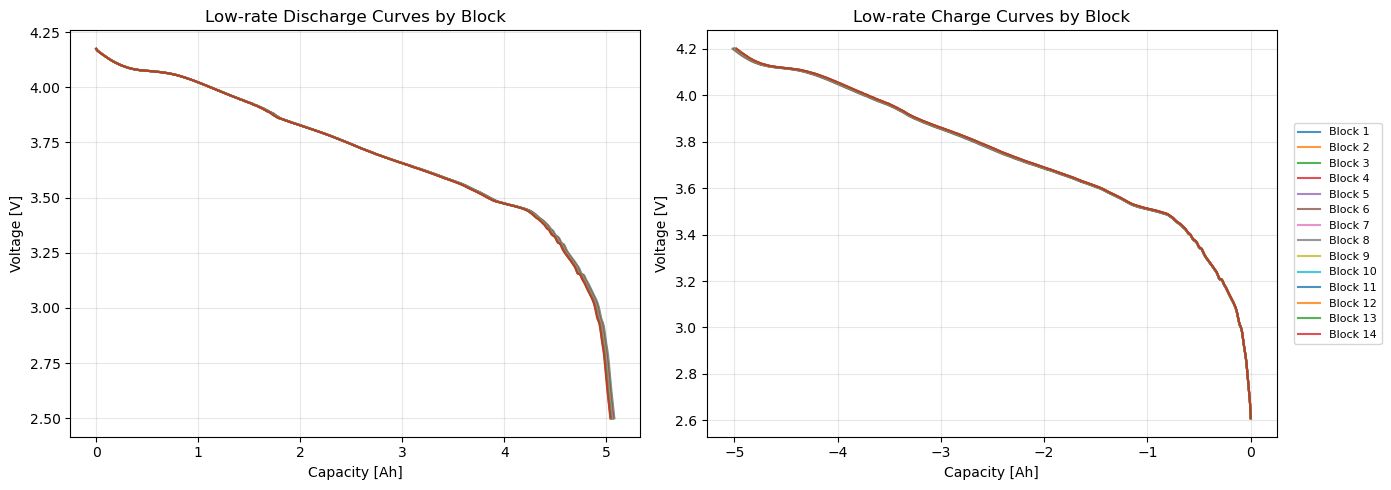

In [7]:
trace_df = pd.read_csv(trace_csv).sort_values(["checkpoint", "trace_role", "time_s"]).reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for checkpoint, group in trace_df.groupby("checkpoint"):
    discharge = group[group["trace_role"] == "low_rate_discharge"]
    charge = group[group["trace_role"] == "low_rate_charge"]
    if not discharge.empty:
        axes[0].plot(discharge["capacity_ah"], discharge["voltage_v"], label=f"Block {checkpoint}", alpha=0.8)
    if not charge.empty:
        axes[1].plot(charge["capacity_ah"], charge["voltage_v"], label=f"Block {checkpoint}", alpha=0.8)
axes[0].set_title("Low-rate Discharge Curves by Block")
axes[0].set_xlabel("Capacity [Ah]")
axes[0].set_ylabel("Voltage [V]")
axes[0].grid(alpha=0.3)
axes[1].set_title("Low-rate Charge Curves by Block")
axes[1].set_xlabel("Capacity [Ah]")
axes[1].set_ylabel("Voltage [V]")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()
fig.savefig(OUT_DIR / "block_charge_discharge_curves.png", dpi=180, bbox_inches="tight")